__Python Memory Management__

Memory management in python involves a combination of automatic garbage collection, reference counting, and various internal optimizations to efficiently manage memory allocation ad deallocation. Understanding these mechanisms can help developers write more efficient and robust applications.

1. Key conecpts in pytho n memory managemnt
2. Memory Allocation and D  EALLOCATION.
    3. rEFRENCE COUNTING
4. Garbage collection
5. The gc module
6. Memory manaagement Best practices

In [1]:
import sys

a=[]
## 3 (on reference from 'a' and one from getrefcount())
print(sys.getrefcount(a))



2


In [2]:
b=a
print(sys.getrefcount(b))

3


In [3]:
del b
print(sys.getrefcount(a))

2


## garbage collection

Python includes a cclic garbage collector to handle reference cycles. Reference cycles occur when objects reference each other, preventong their reference counts from reaching zero.

In [4]:
import gc

## enable garbage collection

gc.enable()

In [5]:
gc.disable()

In [6]:
gc.collect()

196

In [8]:
## get garbage collectionn stats

print(gc.get_stats())

[{'collections': 176, 'collected': 1538, 'uncollectable': 0}, {'collections': 15, 'collected': 260, 'uncollectable': 0}, {'collections': 2, 'collected': 196, 'uncollectable': 0}]


In [9]:
### get unreachable objects

print(gc.garbage)


[]


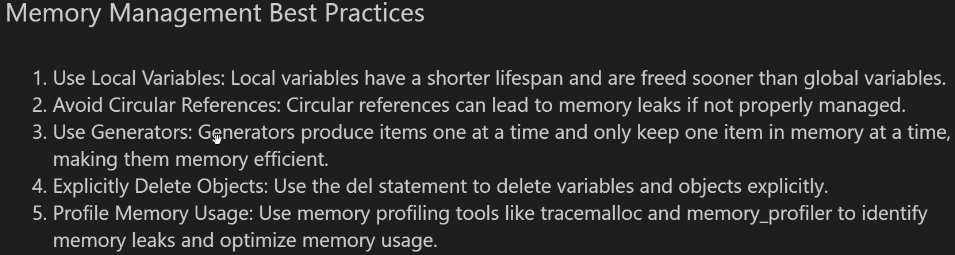

In [12]:
import gc

class MyObject:
    def __init__(self,name):
        self.name=name
        print(f"Object {self.name} created")

    def __del__(self):
        print(f"object {self.name} deleted")

## create circular reference

obj1=MyObject("obj1")
obj2=MyObject("obj2")
obj1.ref=obj2
obj2.ref=obj1

del obj1
del obj2

## Manually trigger the garbage collection
gc.collect()

Object obj1 created
Object obj2 created
object obj1 deleted
object obj2 deleted


9

In [13]:
### Generators for memory efficiency
# ggenerators allow you to produce items one at a time, using memory efficientsly by only keeping one item

def generate_numbers(n):
    for i in range(n):
        yield i

## using the generator
for num in generate_numbers(100000):
    print(num)
    if num>10:
        break

0
1
2
3
4
5
6
7
8
9
10
11


In [16]:
## Profiling Memory usage with tracemalloc

import tracemalloc 

def create_list():
    return [i for i in range(10000)]

def main():
    tracemalloc.start()

    create_list()

    snapshot = tracemalloc.take_snapshot()
    top_stats = snapshot.statistics('lineno')

    print("[ Top 10 ]")
    for stat in top_stats[::]:
        print(stat)

In [17]:
main()

[ Top 10 ]
c:\Users\ASUS\Downloads\python\venv\Lib\json\decoder.py:353: size=1939 B, count=23, average=84 B
c:\Users\ASUS\Downloads\python\venv\Lib\site-packages\IPython\core\interactiveshell.py:1613: size=1520 B, count=1, average=1520 B
c:\Users\ASUS\Downloads\python\venv\Lib\site-packages\zmq\sugar\attrsettr.py:45: size=1316 B, count=28, average=47 B
c:\Users\ASUS\Downloads\python\venv\Lib\contextlib.py:105: size=1256 B, count=12, average=105 B
c:\Users\ASUS\Downloads\python\venv\Lib\codeop.py:118: size=1253 B, count=10, average=125 B
c:\Users\ASUS\Downloads\python\venv\Lib\site-packages\traitlets\traitlets.py:731: size=1154 B, count=18, average=64 B
c:\Users\ASUS\Downloads\python\venv\Lib\site-packages\traitlets\traitlets.py:1543: size=1101 B, count=18, average=61 B
c:\Users\ASUS\Downloads\python\venv\Lib\site-packages\IPython\core\compilerop.py:174: size=1101 B, count=15, average=73 B
c:\Users\ASUS\Downloads\python\venv\Lib\site-packages\zmq\sugar\socket.py:805: size=1056 B, count=